# ECG Denoising — Stage 2 (v3: Null-Space Extended Windows)

**What changed vs v2:**

In Stage 1 we used null-space projection to extend the known window of the
6 limb leads from 2.5 s → 5 s before running beat-template recovery.
This notebook reflects that change in two places:

1. **`get_known_window()`** — replaces the old `get_observed_window()`.  
   For I, III, aVR, aVL, aVF the known window is now **0–5 s** (extended),  
   not the original physical window (0–2.5 s or 2.5–5 s).

2. **`get_missing_mask()`** — updated to mark only samples **outside 0–5 s**  
   as missing for those leads.  SNR is computed only on truly missing samples.

3. **`denoise_and_restore()`** — after projection, the full 0–5 s window is  
   written back from the Stage-1 recovered signal (which already contains  
   exact ground-truth values in the physical window and null-space-projected  
   values in the extended window).

Everything else (projection matrix, batch loop, plots) is identical to v2.

```
Known windows AFTER null-space extension (used in this notebook):

Time:   0 ──── 2.5 ──── 5 ──── 7.5 ──── 10  (seconds)
I    :  ████ real █████ proj ░░░░░░░░░░░░░   known 0–5 s    (was 0–2.5 s)
II   :  ██████████████████████████████████   known 0–10 s   (unchanged)
III  :  ████ real █████ proj ░░░░░░░░░░░░░   known 0–5 s    (was 0–2.5 s)
aVR  :  ████ proj █████ real ░░░░░░░░░░░░░   known 0–5 s    (was 2.5–5 s)
aVL  :  ████ proj █████ real ░░░░░░░░░░░░░   known 0–5 s    (was 2.5–5 s)
aVF  :  ████ proj █████ real ░░░░░░░░░░░░░   known 0–5 s    (was 2.5–5 s)
V1–V3:  ░░░░░░░░░░░░░░░░ real ░░░░░░░░░░░░   known 5–7.5 s  (unchanged)
V4–V6:  ░░░░░░░░░░░░░░░░░░░░░░░░ real ██████  known 7.5–10 s (unchanged)
```

## 1. Imports & Paths

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.io as sio
from pathlib import Path
from scipy.linalg import null_space
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

LEAD_NAMES = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF',
              'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

GROUNDTRUTH_DIR = "/Users/sinahassannia/Desktop/ecg_lead_cover2/gt_clean"
RECOVERED_DIR   = "/Users/sinahassannia/Desktop/ecg_lead_cover2/realigned_ecg3"
OUTPUT_DIR      = "/Users/sinahassannia/Desktop/ecg_lead_cover2/denoised_ecg3/"
RESULTS_DIR     = "/Users/sinahassannia/Desktop/ecg_lead_cover2/denoising_results3/"

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
Path(RESULTS_DIR).mkdir(parents=True, exist_ok=True)

print("✓ Paths configured")
print(f"  Ground truth : {GROUNDTRUTH_DIR}")
print(f"  Recovered    : {RECOVERED_DIR}")
print(f"  Output       : {OUTPUT_DIR}")
print(f"  Results      : {RESULTS_DIR}")

✓ Paths configured
  Ground truth : /Users/sinahassannia/Desktop/ecg_lead_cover2/gt_clean
  Recovered    : /Users/sinahassannia/Desktop/ecg_lead_cover2/realigned_ecg3
  Output       : /Users/sinahassannia/Desktop/ecg_lead_cover2/denoised_ecg3/
  Results      : /Users/sinahassannia/Desktop/ecg_lead_cover2/denoising_results3/


## 2. Known-Window Map & Missing Mask

**`get_known_window(lead, fs)`** — returns the **(start, end)** sample indices
of the window that is **known** for each lead after Stage-1 null-space
extension.  For the 5 extended limb leads this is now **0–5 s** instead of
the original 2.5-second physical window.

**`get_physical_window(lead, fs)`** — the original physical measurement window
(needed when we restore exact GT values back into the denoised signal).

**`get_missing_mask(lead, N, fs)`** — `True` only for samples that were
**genuinely recovered by beat-template** (i.e. outside the known window).
SNR is computed only on these samples.

In [2]:
def get_physical_window(lead, fs=500):
    """
    Original physical measurement window for each lead (before any projection).
    Used only to restore exact ground-truth values after denoising.
    """
    if lead == 'II':
        return (0, None)                              # full signal
    elif lead in ('I', 'III'):
        return (0, int(2.5 * fs))                     # 0–2.5 s
    elif lead in ('aVR', 'aVL', 'aVF'):
        return (int(2.5 * fs), int(5.0 * fs))         # 2.5–5 s
    elif lead in ('V1', 'V2', 'V3'):
        return (int(5.0 * fs), int(7.5 * fs))         # 5–7.5 s
    elif lead in ('V4', 'V5', 'V6'):
        return (int(7.5 * fs), int(10.0 * fs))        # 7.5–10 s
    else:
        raise ValueError(f"Unknown lead: {lead}")


def get_known_window(lead, fs=500):
    """
    Effective known window AFTER Stage-1 null-space projection.

    For I, III, aVR, aVL, aVF the window is extended to 0–5 s:
      - I, III   : physically observed 0–2.5 s  + projected 2.5–5 s  → known 0–5 s
      - aVR/L/F  : projected 0–2.5 s + physically observed 2.5–5 s   → known 0–5 s

    All other leads are unchanged.
    """
    if lead == 'II':
        return (0, None)                              # full signal
    elif lead in ('I', 'III', 'aVR', 'aVL', 'aVF'):
        return (0, int(5.0 * fs))                     # 0–5 s  ← EXTENDED
    elif lead in ('V1', 'V2', 'V3'):
        return (int(5.0 * fs), int(7.5 * fs))         # 5–7.5 s (unchanged)
    elif lead in ('V4', 'V5', 'V6'):
        return (int(7.5 * fs), int(10.0 * fs))        # 7.5–10 s (unchanged)
    else:
        raise ValueError(f"Unknown lead: {lead}")


def get_missing_mask(lead, N, fs=500):
    """
    Boolean mask of length N: True for every sample that was NOT physically
    measured — i.e. everything outside get_physical_window().

    This includes BOTH the null-space projected segment (derived, not measured)
    AND the beat-template recovered segment.  Both are reconstruction outputs
    and must be included when evaluating SNR on the missing region.

    Correct missing regions:
      I, III        → 2.5–10 s   (projected 2.5–5 s  + beat-recovered 5–10 s)
      aVR, aVL, aVF → 0–2.5 s + 5–10 s  (projected 0–2.5 s + beat-recovered 5–10 s)
      V1–V3         → 0–5 s + 7.5–10 s
      V4–V6         → 0–7.5 s
      II            → nothing missing

    Lead II → all False (nothing is missing).
    """
    phys_start, phys_end = get_physical_window(lead, fs)
    if phys_end is None:                   # Lead II — fully observed
        return np.zeros(N, dtype=bool)
    mask = np.ones(N, dtype=bool)          # start: everything missing
    mask[phys_start:phys_end] = False      # only physically measured samples are NOT missing
    return mask


# ── Sanity check ────────────────────────────────────────────────────────────
fs = 500
N  = 5000
print("Physical windows and corrected missing fraction per lead:")
print(f"{'Lead':<6} {'Phys window':<14} {'Known window':<14} "
      f"{'Missing samples (physical excluded)':>36} {'Missing %':>10}")
print("-" * 64)
for lead in LEAD_NAMES:
    ps, pe   = get_physical_window(lead, fs)
    ks, ke   = get_known_window(lead, fs)
    pe_disp  = pe if pe is not None else N
    ke_disp  = ke if ke is not None else N
    missing  = get_missing_mask(lead, N, fs)
    phys_str = f"{ps/fs:.1f}–{pe_disp/fs:.1f}s"
    known_str= f"{ks/fs:.1f}–{ke_disp/fs:.1f}s"
    print(f"{lead:<6} {phys_str:<14} {known_str:<14} "
          f"{missing.sum():>16} {100*missing.mean():>9.1f}%")

Physical windows and corrected missing fraction per lead:
Lead   Phys window    Known window    Missing samples (physical excluded)  Missing %
----------------------------------------------------------------
I      0.0–2.5s       0.0–5.0s                   3750      75.0%
II     0.0–10.0s      0.0–10.0s                     0       0.0%
III    0.0–2.5s       0.0–5.0s                   3750      75.0%
aVR    2.5–5.0s       0.0–5.0s                   3750      75.0%
aVL    2.5–5.0s       0.0–5.0s                   3750      75.0%
aVF    2.5–5.0s       0.0–5.0s                   3750      75.0%
V1     5.0–7.5s       5.0–7.5s                   3750      75.0%
V2     5.0–7.5s       5.0–7.5s                   3750      75.0%
V3     5.0–7.5s       5.0–7.5s                   3750      75.0%
V4     7.5–10.0s      7.5–10.0s                  3750      75.0%
V5     7.5–10.0s      7.5–10.0s                  3750      75.0%
V6     7.5–10.0s      7.5–10.0s                  3750      75.0%


## 3. Constraint Matrix & Projection Matrix

Unchanged from v2 — the projection matrix P acts on all 12 leads.

In [3]:
def construct_constraint_matrix():
    """
    4 linear constraints on the 12 ECG leads (Einthoven + augmented leads).
    Only the 6 limb leads (columns 0–5) have non-zero entries.
    Shape: (4, 12)
    """
    A = np.zeros((4, 12))
    A[0, [0, 1, 2]] = [ 1, -1,  1]   # I - II + III = 0
    A[1, [0, 1, 3]] = [ 1,  1,  2]   # I + II + 2·aVR = 0
    A[2, [0, 1, 4]] = [ 2, -1, -2]   # 2·I - II - 2·aVL = 0
    A[3, [0, 1, 5]] = [-1,  2, -2]   # -I + 2·II - 2·aVF = 0
    return A


def compute_projection_matrix_null(A):
    """
    Orthogonal projector onto null(A):
      P = I - A^T (A A^T)^{-1} A
    Forces the projected signal to satisfy all 4 ECG constraints exactly.
    """
    n   = A.shape[1]
    AAT = A @ A.T
    P   = np.eye(n) - A.T @ np.linalg.pinv(AAT) @ A
    return P


A      = construct_constraint_matrix()
P_null = compute_projection_matrix_null(A)

print("Constraint matrix A:")
print(f"  Shape           : {A.shape}")
print(f"  Rank            : {np.linalg.matrix_rank(A)}")
print(f"  Null-space dim  : {null_space(A).shape[1]}")
print(f"\nProjection matrix P_null:")
print(f"  Shape           : {P_null.shape}")
print(f"  Idempotent P²=P : {np.allclose(P_null @ P_null, P_null)}")
print(f"  Symmetric       : {np.allclose(P_null, P_null.T)}")
print(f"  A @ P = 0       : {np.allclose(A @ P_null, 0)}")

Constraint matrix A:
  Shape           : (4, 12)
  Rank            : 4
  Null-space dim  : 8

Projection matrix P_null:
  Shape           : (12, 12)
  Idempotent P²=P : True
  Symmetric       : True
  A @ P = 0       : True


## 4. Data Loading Functions

In [4]:
def load_groundtruth(record_name, ecg_dir,
                     selected_leads=['I', 'II', 'III', 'aVR', 'aVL', 'aVF',
                                     'V1', 'V2', 'V3', 'V4', 'V5', 'V6']):
    """
    Load GT from a .mat file.
    Returns (signal (12, N), record).
    """
    record_id = int(record_name.split('_')[0])
    folder_id = (record_id - 1) // 1000 * 1000
    mat_path  = Path(ecg_dir) / f"{folder_id:05d}" / (record_name + '.mat')

    data       = sio.loadmat(str(mat_path), squeeze_me=True)
    ecg        = data['ecg'].astype(np.float64)
    lead_names = list(data['lead_names'])

    if ecg.ndim == 2 and ecg.shape[0] < ecg.shape[1]:
        ecg = ecg.T   # ensure (N, 12)

    if selected_leads is not None:
        available = {str(n).strip().lower(): (str(n), i)
                     for i, n in enumerate(lead_names)}
        lead_indices, found_leads = [], []
        for req in selected_leads:
            key = req.strip().lower()
            if key in available:
                actual, idx = available[key]
                lead_indices.append(idx)
                found_leads.append(actual)
        ecg        = ecg[:, lead_indices]
        lead_names = found_leads

    fs = float(data['fs'])

    class Record:
        def __init__(self, sig_name, fs, record_name):
            self.sig_name    = sig_name
            self.fs          = fs
            self.record_name = record_name

    record = Record(lead_names, fs, str(data['record_name']))
    return ecg.T, record   # → (12, N)


def load_recovered(record_name, recovered_dir):
    """
    Load Stage-1 recovered signal (after realignment) → (12, N).
    The .npy file contains the full 10-second 12-lead signal.
    The known window (0–5 s for limb leads) already holds the correct values
    (real GT for physical window, null-space projected for extended window).
    """
    record_id = int(record_name.split('_')[0])
    folder_id = (record_id - 1) // 1000 * 1000
    npy_path  = Path(recovered_dir) / f"{folder_id:05d}" / f"{record_name}.npy"
    X = np.load(npy_path).astype(np.float64)
    if X.ndim == 2 and X.shape[0] > X.shape[1]:
        X = X.T   # ensure (12, N)
    return X


print("✓ Data loading functions defined")

✓ Data loading functions defined


## 5. Denoising & SNR Helpers

**Key change in `denoise_and_restore()`:**  
After null-space projection we now restore the full **known window (0–5 s)**
for I, III, aVR, aVL, aVF from the Stage-1 recovered signal `X_rec`
(which already holds the correct values there), not just the physical window.
Only the physically measured samples are restored from the true GT `X_gt`.

Concretely for Lead I:
```
0–2.5 s  → restore from X_gt   (physical measurement, exact)
2.5–5 s  → restore from X_rec  (null-space projected, very accurate)
5–10 s   → keep the denoised projection output (beat-template region)
```

In [5]:
def compute_snr(x_true, x_est):
    """Full-signal SNR in dB."""
    err   = x_true - x_est
    P_sig = np.mean(x_true ** 2)
    P_err = np.mean(err ** 2)
    return np.inf if P_err < 1e-12 else 10 * np.log10(P_sig / P_err)


def compute_snr_missing(x_true, x_est, mask):
    """
    SNR restricted to the truly missing (beat-template reconstructed) region.
    mask: boolean array, True where samples are missing.
    """
    if mask.sum() == 0:
        return np.inf
    err   = x_true[mask] - x_est[mask]
    P_sig = np.mean(x_true[mask] ** 2)
    P_err = np.mean(err ** 2)
    return np.inf if P_err < 1e-12 else 10 * np.log10(P_sig / P_err)


def denoise_and_restore(X_recovered, X_gt, P_null, fs=500):
    """
    1. Project X_recovered onto null(A)  →  removes constraint-violating noise.
    2. Restore the KNOWN window from the appropriate source:
         - Physical window  → from X_gt   (exact ground truth)
         - Extended window  → from X_rec  (null-space projected, kept as-is)
       This preserves the first 5 s of I, III, aVR, aVL, aVF exactly as
       they came out of Stage 1, while still correcting the beat-template
       region (5–10 s) via the null-space projection.

    Args:
        X_recovered : (12, N) recovered signal from Stage 1
        X_gt        : (12, N) ground-truth signal
        P_null      : (12, 12) null-space projection matrix
        fs          : sampling rate

    Returns:
        X_denoised  : (12, N)
    """
    N          = X_recovered.shape[1]
    X_denoised = P_null @ X_recovered   # project all 5000 samples at once

    for ch, lead in enumerate(LEAD_NAMES):

        phys_start, phys_end = get_physical_window(lead, fs)
        kn_start,   kn_end   = get_known_window(lead, fs)

        if kn_end is None:
            # Lead II: fully observed — restore everything from GT
            X_denoised[ch, :] = X_gt[ch, :]

        elif lead in ('I', 'III', 'aVR', 'aVL', 'aVF'):
            # Extended limb leads: known window is 0–5 s
            # Restore the entire known window from X_recovered first
            # (it already has the null-space projected values for the
            #  non-physical half and exact GT for the physical half)
            X_denoised[ch, kn_start:kn_end] = X_recovered[ch, kn_start:kn_end]

            # Then overwrite the physical window with exact GT
            if phys_end is None:
                X_denoised[ch, phys_start:] = X_gt[ch, phys_start:]
            else:
                X_denoised[ch, phys_start:phys_end] = X_gt[ch, phys_start:phys_end]

        else:
            # Chest leads and their physical windows (unchanged behaviour)
            if phys_end is None:
                X_denoised[ch, phys_start:] = X_gt[ch, phys_start:]
            else:
                X_denoised[ch, phys_start:phys_end] = X_gt[ch, phys_start:phys_end]

    return X_denoised


def verify_constraints(X, A):
    """Relative constraint residual ||A X||_F / ||X||_F."""
    return np.linalg.norm(A @ X) / (np.linalg.norm(X) + 1e-30)


print("✓ Denoising & SNR helpers defined")

✓ Denoising & SNR helpers defined


## 6. Single-Record Processing Pipeline

In [6]:
def process_record(record_name, groundtruth_dir, recovered_dir, output_dir,
                   P_null, A, fs=500, verbose=True):
    """
    Full denoising pipeline for one record.

    SNR metrics:
      snr_*_missing : only on truly missing samples (outside PHYSICAL window).
                      Includes null-space projected segment + beat-template segment.
      snr_*_full    : over entire 10 s

    Correct missing regions used for SNR:
      I, III        → 2.5–10 s
      aVR, aVL, aVF → 0–2.5 s + 5–10 s
      V1–V3         → 0–5 s + 7.5–10 s
      V4–V6         → 0–7.5 s

    Returns dict with all signals and metrics, or None on failure.
    """
    try:
        X_gt,  record = load_groundtruth(record_name, groundtruth_dir)
        X_rec         = load_recovered(record_name, recovered_dir)
        N             = X_gt.shape[1]

        # Align lengths if needed
        if X_gt.shape[1] != X_rec.shape[1]:
            N    = min(X_gt.shape[1], X_rec.shape[1])
            X_gt  = X_gt[:, :N]
            X_rec = X_rec[:, :N]

        # ── Denoise (project + restore known window) ──────────────────────
        X_den = denoise_and_restore(X_rec, X_gt, P_null, fs)

        # ── Per-lead SNR on missing region only ───────────────────────────
        snr_rec_missing = {}
        snr_den_missing = {}
        snr_rec_full    = {}
        snr_den_full    = {}

        for ch, lead in enumerate(LEAD_NAMES):
            # Missing mask uses the EXTENDED known window
            mask = get_missing_mask(lead, N, fs)
            snr_rec_missing[lead] = compute_snr_missing(X_gt[ch], X_rec[ch], mask)
            snr_den_missing[lead] = compute_snr_missing(X_gt[ch], X_den[ch], mask)
            snr_rec_full[lead]    = compute_snr(X_gt[ch], X_rec[ch])
            snr_den_full[lead]    = compute_snr(X_gt[ch], X_den[ch])

        # ── Overall SNR (mean over non-II leads, missing region) ──────────
        vals_rec = [v for k, v in snr_rec_missing.items()
                    if k != 'II' and np.isfinite(v)]
        vals_den = [v for k, v in snr_den_missing.items()
                    if k != 'II' and np.isfinite(v)]
        overall_rec = np.mean(vals_rec) if vals_rec else np.nan
        overall_den = np.mean(vals_den) if vals_den else np.nan

        # ── Constraint errors ─────────────────────────────────────────────
        ce_rec = verify_constraints(X_rec, A)
        ce_den = verify_constraints(X_den, A)

        # ── Save denoised signal ──────────────────────────────────────────
        record_id = int(record_name.split('_')[0])
        folder_id = (record_id - 1) // 1000 * 1000
        out_path  = Path(output_dir) / f"{folder_id:05d}" / f"{record_name}.npy"
        out_path.parent.mkdir(parents=True, exist_ok=True)
        np.save(out_path, X_den.astype(np.float32))

        result = dict(
            record            = record_name,
            X_gt              = X_gt,
            X_recovered       = X_rec,
            X_denoised        = X_den,
            snr_rec_missing   = snr_rec_missing,
            snr_den_missing   = snr_den_missing,
            snr_rec_full      = snr_rec_full,
            snr_den_full      = snr_den_full,
            overall_rec       = overall_rec,
            overall_den       = overall_den,
            snr_improvement   = overall_den - overall_rec,
            ce_rec            = ce_rec,
            ce_den            = ce_den,
            saved_path        = str(out_path),
            fs                = fs,
            N                 = N,
        )

        if verbose:
            print(f"\n✓ {record_name}")
            print(f"  SNR (missing region): {overall_rec:.2f} → {overall_den:.2f} dB "
                  f"(Δ {overall_den - overall_rec:+.2f} dB)")
            print(f"  Constraints: {ce_rec:.2e} → {ce_den:.2e}")

        return result

    except Exception as e:
        print(f"✗ Error processing {record_name}: {e}")
        import traceback; traceback.print_exc()
        return None


print("✓ process_record() defined")

✓ process_record() defined


## 7. Single-Record Test

In [7]:
TEST_RECORD = "00001_hr"

result = process_record(
    TEST_RECORD, GROUNDTRUTH_DIR, RECOVERED_DIR, OUTPUT_DIR,
    P_null, A, verbose=True
)

if result:
    fs = result['fs']
    N  = result['N']

    print(f"\n{'='*78}")
    print(f"DETAILED METRICS — {TEST_RECORD}")
    print(f"SNR computed on missing region (outside extended known window)")
    print(f"{'='*78}")
    print(f"\n{'Lead':<6} {'Known window':<14} {'Rec miss (dB)':>14} "
          f"{'Den miss (dB)':>14} {'Δ (dB)':>8} "
          f"{'Rec full (dB)':>14} {'Den full (dB)':>14}")
    print("-" * 88)

    for lead in LEAD_NAMES:
        ks, ke  = get_known_window(lead, fs)
        ke_disp = ke if ke is not None else N
        kw_str  = f"{ks/fs:.1f}–{ke_disp/fs:.1f}s"
        sr_m = result['snr_rec_missing'][lead]
        sd_m = result['snr_den_missing'][lead]
        sr_f = result['snr_rec_full'][lead]
        sd_f = result['snr_den_full'][lead]
        delta = sd_m - sr_m if (np.isfinite(sd_m) and np.isfinite(sr_m)) else np.nan
        tag = "← extended" if lead in ('I','III','aVR','aVL','aVF') else ""
        print(f"{lead:<6} {kw_str:<14} {sr_m:>14.2f} {sd_m:>14.2f} "
              f"{delta:>+8.2f} {sr_f:>14.2f} {sd_f:>14.2f}  {tag}")

    print(f"\n  Constraint error  recovered : {result['ce_rec']:.2e}")
    print(f"  Constraint error  denoised  : {result['ce_den']:.2e}")


✓ 00001_hr
  SNR (missing region): 4.21 → 4.48 dB (Δ +0.27 dB)
  Constraints: 4.02e-01 → 3.46e-01

DETAILED METRICS — 00001_hr
SNR computed on missing region (outside extended known window)

Lead   Known window    Rec miss (dB)  Den miss (dB)   Δ (dB)  Rec full (dB)  Den full (dB)
----------------------------------------------------------------------------------------
I      0.0–5.0s                 3.06           3.37    +0.30           4.89           5.20  ← extended
II     0.0–10.0s                 inf            inf     +nan            inf            inf  
III    0.0–5.0s                -1.23          -1.10    +0.13           0.67           0.80  ← extended
aVR    0.0–5.0s                 4.78           5.75    +0.97           5.94           6.91  ← extended
aVL    0.0–5.0s                 1.52           1.37    -0.15           2.44           2.29  ← extended
aVF    0.0–5.0s                 0.78           2.52    +1.75           2.04           3.79  ← extended
V1     5.0–7.5s     

## 8. Verification — Known Window Preserved Exactly

For each extended limb lead:
- **Physical window** (0–2.5 s for I/III, 2.5–5 s for aVR/aVL/aVF):  
  denoised signal must equal ground truth exactly.
- **Projected window** (the other half of 0–5 s):  
  denoised signal must equal the Stage-1 recovered signal exactly  
  (projection values are preserved, not GT).

In [8]:
if result:
    X_gt  = result['X_gt']
    X_rec = result['X_recovered']
    X_den = result['X_denoised']
    fs    = result['fs']
    N     = result['N']

    s_25 = int(2.5 * fs)
    s_50 = int(5.0 * fs)

    print("Verification of known-window preservation after denoising")
    print(f"{'Lead':<6} {'Segment':<22} {'Source':<12} {'Max |err|':>12} {'Pass?':>8}")
    print("-" * 64)

    checks = [
        # (lead, slice, reference, description)
        ('I',   slice(0,    s_25), X_gt,  "GT",  "0–2.5s (physical)"),
        ('I',   slice(s_25, s_50), X_rec, "Rec", "2.5–5s (projected)"),
        ('III', slice(0,    s_25), X_gt,  "GT",  "0–2.5s (physical)"),
        ('III', slice(s_25, s_50), X_rec, "Rec", "2.5–5s (projected)"),
        ('aVR', slice(0,    s_25), X_rec, "Rec", "0–2.5s (projected)"),
        ('aVR', slice(s_25, s_50), X_gt,  "GT",  "2.5–5s (physical)"),
        ('aVL', slice(0,    s_25), X_rec, "Rec", "0–2.5s (projected)"),
        ('aVL', slice(s_25, s_50), X_gt,  "GT",  "2.5–5s (physical)"),
        ('aVF', slice(0,    s_25), X_rec, "Rec", "0–2.5s (projected)"),
        ('aVF', slice(s_25, s_50), X_gt,  "GT",  "2.5–5s (physical)"),
    ]

    for lead, sl, ref, src, desc in checks:
        ch      = LEAD_NAMES.index(lead)
        max_err = np.abs(X_den[ch, sl] - ref[ch, sl]).max()
        passed  = "✓ YES" if max_err < 1e-5 else "✗ NO"
        print(f"{lead:<6} {desc:<22} {src:<12} {max_err:>12.2e} {passed:>8}")

Verification of known-window preservation after denoising
Lead   Segment                Source          Max |err|    Pass?
----------------------------------------------------------------
I      0–2.5s (physical)      GT               0.00e+00    ✓ YES
I      2.5–5s (projected)     Rec              0.00e+00    ✓ YES
III    0–2.5s (physical)      GT               0.00e+00    ✓ YES
III    2.5–5s (projected)     Rec              0.00e+00    ✓ YES
aVR    0–2.5s (projected)     Rec              0.00e+00    ✓ YES
aVR    2.5–5s (physical)      GT               0.00e+00    ✓ YES
aVL    0–2.5s (projected)     Rec              0.00e+00    ✓ YES
aVL    2.5–5s (physical)      GT               0.00e+00    ✓ YES
aVF    0–2.5s (projected)     Rec              0.00e+00    ✓ YES
aVF    2.5–5s (physical)      GT               0.00e+00    ✓ YES


## 9. Visualization — Lead aVF

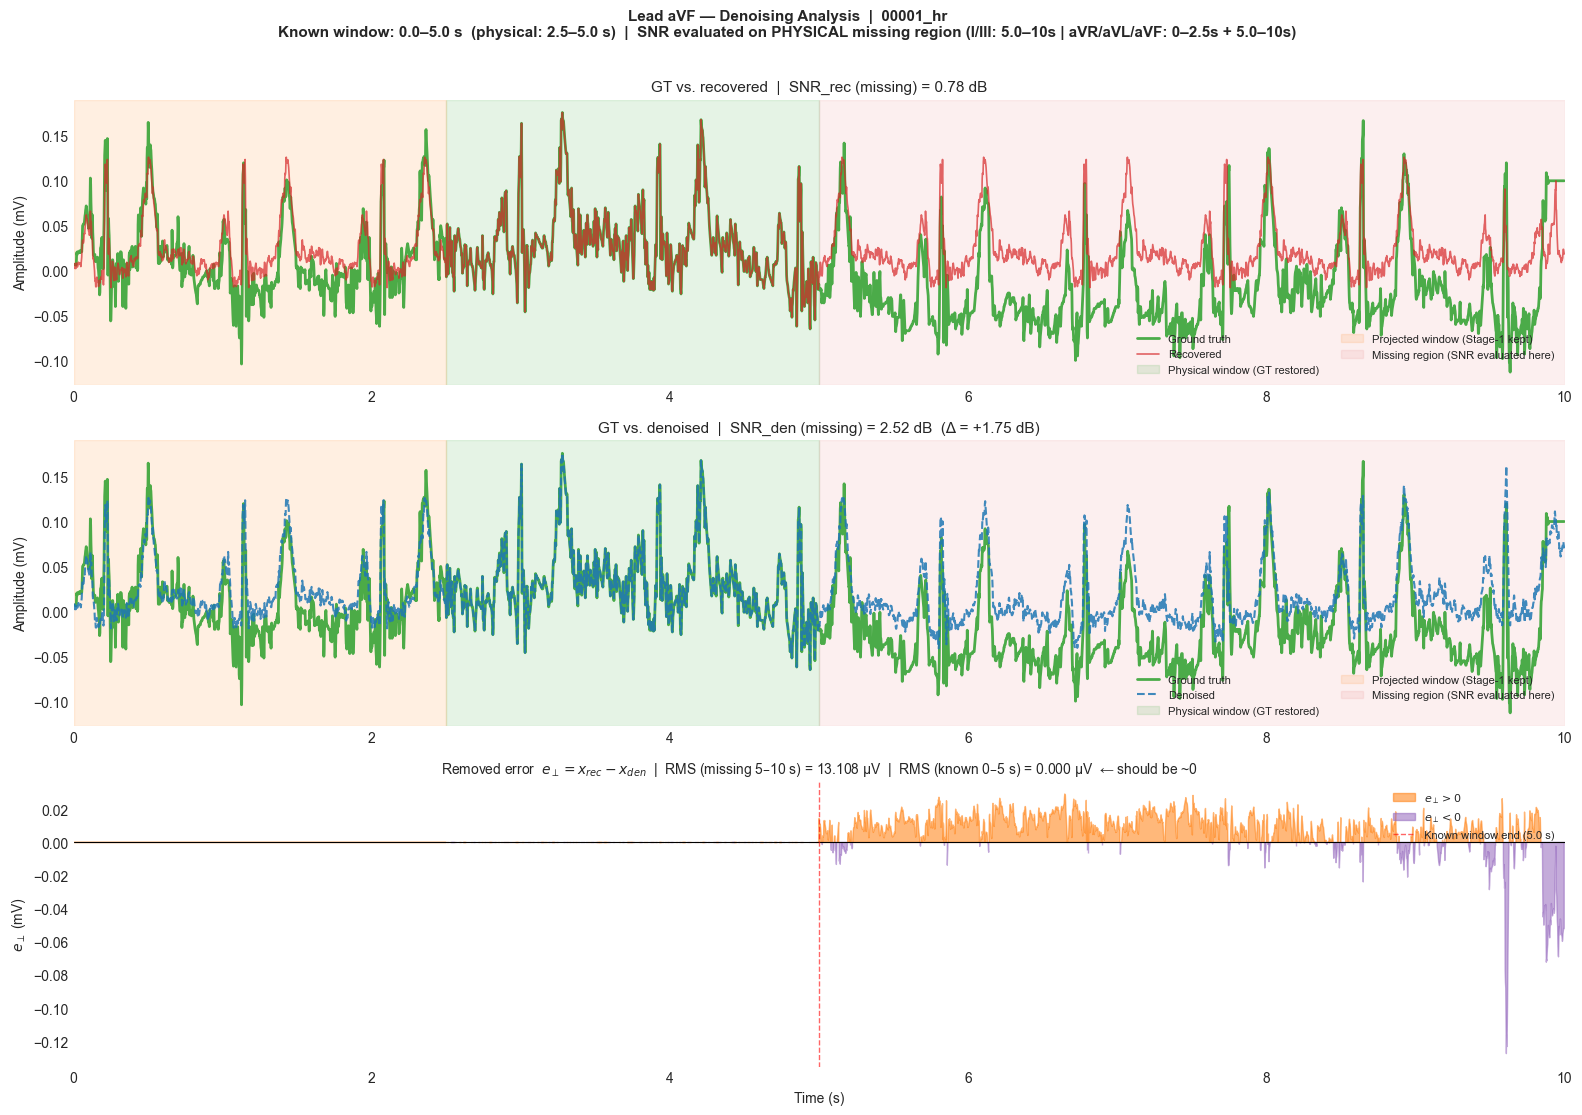

✓ Saved → /Users/sinahassannia/Desktop/ecg_lead_cover2/denoising_results3/aVF_denoising_00001_hr.png
  SNR_rec (missing) : 0.78 dB
  SNR_den (missing) : 2.52 dB
  Δ SNR             : +1.75 dB
  e_perp RMS (missing 5–10 s) : 13.108 µV
  e_perp RMS (known  0–5  s)  : 0.000 µV  ← should be ~0


In [9]:
if result:
    LEAD_PLOT = 'aVF'
    ch_idx    = LEAD_NAMES.index(LEAD_PLOT)
    fs        = result['fs']
    N         = result['N']
    t_full    = np.arange(N) / fs

    gt        = result['X_gt'][ch_idx]
    recovered = result['X_recovered'][ch_idx]
    denoised  = result['X_denoised'][ch_idx]
    e_perp    = recovered - denoised

    # Known window for aVF is 0–5 s (extended)
    kn_s, kn_e = get_known_window(LEAD_PLOT, fs)
    # Physical window for aVF is 2.5–5 s
    ph_s, ph_e = get_physical_window(LEAD_PLOT, fs)
    mask_avf   = get_missing_mask(LEAD_PLOT, N, fs)

    snr_r = result['snr_rec_missing'][LEAD_PLOT]
    snr_d = result['snr_den_missing'][LEAD_PLOT]
    delta = snr_d - snr_r if (np.isfinite(snr_d) and np.isfinite(snr_r)) else 0.0

    plt.rcParams['axes.facecolor']  = 'white'
    plt.rcParams['figure.facecolor'] = 'white'

    fig, axes = plt.subplots(3, 1, figsize=(16, 11))
    fig.suptitle(
        f'Lead {LEAD_PLOT} — Denoising Analysis  |  {TEST_RECORD}\n'
        f'Known window: {kn_s/fs:.1f}–{kn_e/fs:.1f} s  '
        f'(physical: {ph_s/fs:.1f}–{ph_e/fs:.1f} s)  |  '
        f'SNR evaluated on PHYSICAL missing region '
        f'(I/III: {ph_e/fs:.1f}–10s | aVR/aVL/aVF: 0–{ph_s/fs:.1f}s + {ph_e/fs:.1f}–10s)',
        fontsize=11, fontweight='bold', y=1.01
    )

    def add_window_shading(ax):
        """Add shading for projected (orange) and physical (green) windows."""
        # Projected sub-window within 0–5 s
        if LEAD_PLOT in ('I', 'III'):
            proj_s, proj_e = ph_e / fs, kn_e / fs   # 2.5–5 s is projected
            phys_s, phys_e_t = kn_s / fs, ph_e / fs   # 0–2.5 s is physical
        else:  # aVR/aVL/aVF
            proj_s, proj_e = kn_s / fs, ph_s / fs   # 0–2.5 s is projected
            phys_s, phys_e_t = ph_s / fs, ph_e / fs   # 2.5–5 s is physical
        ax.axvspan(phys_s, phys_e_t, alpha=0.12, color='#2ca02c',
                   label='Physical window (GT restored)')
        ax.axvspan(proj_s, proj_e,   alpha=0.12, color='#ff7f0e',
                   label='Projected window (Stage-1 kept)')
        # Missing region (beat-template)
        ax.axvspan(kn_e / fs, 10.0, alpha=0.07, color='#d62728',
                   label='Missing region (SNR evaluated here)')

    # ── Row 1: GT vs recovered ────────────────────────────────────────────
    ax = axes[0]
    ax.plot(t_full, gt,        color='#2ca02c', lw=2,   alpha=0.85, label='Ground truth')
    ax.plot(t_full, recovered, color='#d62728', lw=1.2, alpha=0.7,  label='Recovered')
    add_window_shading(ax)
    ax.set_title(f'GT vs. recovered  |  SNR_rec (missing) = {snr_r:.2f} dB', fontsize=11)
    ax.set_ylabel('Amplitude (mV)')
    ax.legend(loc='lower right', fontsize=8, ncol=2)
    ax.grid(True, alpha=0.25)
    ax.set_xlim(0, 10)

    # ── Row 2: GT vs denoised ─────────────────────────────────────────────
    ax = axes[1]
    ax.plot(t_full, gt,       color='#2ca02c', lw=2,   alpha=0.85, label='Ground truth')
    ax.plot(t_full, denoised, color='#1f77b4', lw=1.5, alpha=0.85,
            ls='--', label='Denoised')
    add_window_shading(ax)
    ax.set_title(
        f'GT vs. denoised  |  SNR_den (missing) = {snr_d:.2f} dB  '
        f'(Δ = {delta:+.2f} dB)', fontsize=11
    )
    ax.set_ylabel('Amplitude (mV)')
    ax.legend(loc='lower right', fontsize=8, ncol=2)
    ax.grid(True, alpha=0.25)
    ax.set_xlim(0, 10)

    # ── Row 3: removed error e_perp ──────────────────────────────────────
    ax = axes[2]
    ax.fill_between(t_full, e_perp, 0,
                    where=(e_perp >= 0), color='#ff7f0e', alpha=0.55,
                    label='$e_\perp > 0$')
    ax.fill_between(t_full, e_perp, 0,
                    where=(e_perp < 0),  color='#9467bd', alpha=0.55,
                    label='$e_\perp < 0$')
    ax.axhline(0, color='black', lw=0.8)
    # Mark the known window boundaries
    ax.axvline(kn_e / fs, color='red', lw=1, ls='--', alpha=0.6,
               label=f'Known window end ({kn_e/fs:.1f} s)')
    rms_missing = np.sqrt(np.mean(e_perp[mask_avf] ** 2)) * 1000
    rms_known   = np.sqrt(np.mean(e_perp[~mask_avf] ** 2)) * 1000
    ax.set_ylabel('$e_\perp$ (mV)')
    ax.set_xlabel('Time (s)')
    ax.set_title(
        f'Removed error  $e_\perp = x_{{rec}} - x_{{den}}$  |  '
        f'RMS (missing 5–10 s) = {rms_missing:.3f} µV  |  '
        f'RMS (known 0–5 s) = {rms_known:.3f} µV  ← should be ~0',
        fontsize=10
    )
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.25)
    ax.set_xlim(0, 10)

    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}{LEAD_PLOT}_denoising_{TEST_RECORD}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved → {RESULTS_DIR}{LEAD_PLOT}_denoising_{TEST_RECORD}.png")
    print(f"  SNR_rec (missing) : {snr_r:.2f} dB")
    print(f"  SNR_den (missing) : {snr_d:.2f} dB")
    print(f"  Δ SNR             : {delta:+.2f} dB")
    print(f"  e_perp RMS (missing 5–10 s) : {rms_missing:.3f} µV")
    print(f"  e_perp RMS (known  0–5  s)  : {rms_known:.3f} µV  ← should be ~0")

## 10. Batch Processing

In [10]:
all_npy_files = list(Path(RECOVERED_DIR).glob('*/*.npy'))
print(f"Found {len(all_npy_files)} recovered records\n")

results_list = []
for i, npy_file in enumerate(all_npy_files):
    record_name = npy_file.stem
    res = process_record(
        record_name, GROUNDTRUTH_DIR, RECOVERED_DIR, OUTPUT_DIR,
        P_null, A, verbose=False
    )
    if res:
        results_list.append(res)
        if (i + 1) % 500 == 0:
            print(f"  [{i+1}/{len(all_npy_files)}]  "
                  f"last SNR: {res['overall_rec']:.1f} → {res['overall_den']:.1f} dB")

print(f"\n✓ Processed {len(results_list)}/{len(all_npy_files)} records successfully")

Found 20624 recovered records

  [500/20624]  last SNR: 3.0 → 3.2 dB
  [1000/20624]  last SNR: 1.2 → 1.4 dB
  [1500/20624]  last SNR: 4.7 → 5.3 dB
  [2000/20624]  last SNR: 12.8 → 13.2 dB
  [2500/20624]  last SNR: 17.9 → 18.3 dB
  [3000/20624]  last SNR: 8.1 → 8.3 dB
  [3500/20624]  last SNR: 3.2 → 3.6 dB
  [4000/20624]  last SNR: 14.8 → 15.2 dB
  [4500/20624]  last SNR: 3.9 → 5.5 dB
  [5000/20624]  last SNR: 5.4 → 6.3 dB
  [5500/20624]  last SNR: 12.4 → 13.0 dB
  [6000/20624]  last SNR: 9.1 → 9.6 dB
  [6500/20624]  last SNR: 9.3 → 9.7 dB
  [7000/20624]  last SNR: 17.8 → 18.1 dB
  [7500/20624]  last SNR: 4.4 → 5.2 dB
  [8000/20624]  last SNR: 8.5 → 8.9 dB
  [8500/20624]  last SNR: 5.1 → 5.7 dB
  [9000/20624]  last SNR: 6.4 → 6.8 dB
  [9500/20624]  last SNR: 7.7 → 7.9 dB
  [10000/20624]  last SNR: 8.3 → 8.9 dB
  [10500/20624]  last SNR: 12.6 → 12.8 dB
  [11000/20624]  last SNR: 10.8 → 11.7 dB
  [11500/20624]  last SNR: 5.0 → 5.4 dB
  [12000/20624]  last SNR: 15.5 → 15.7 dB
  [12500/2062

## 11. Aggregate Summary

In [11]:
if results_list:
    rows = []
    for lead in LEAD_NAMES:
        if lead == 'II':
            continue
        sr_vals = [r['snr_rec_missing'][lead] for r in results_list
                   if np.isfinite(r['snr_rec_missing'][lead])]
        sd_vals = [r['snr_den_missing'][lead] for r in results_list
                   if np.isfinite(r['snr_den_missing'][lead])]
        if not sr_vals:
            continue
        ks, ke  = get_known_window(lead, 500)
        ke_disp = ke if ke is not None else 5000
        rows.append({
            'Lead'           : lead,
            'Known window'   : f"{ks/500:.1f}–{ke_disp/500:.1f}s",
            'N'              : len(sr_vals),
            'Rec mean (dB)'  : np.mean(sr_vals),
            'Rec std  (dB)'  : np.std(sr_vals),
            'Den mean (dB)'  : np.mean(sd_vals),
            'Den std  (dB)'  : np.std(sd_vals),
            'Δ mean   (dB)'  : np.mean(sd_vals) - np.mean(sr_vals),
        })

    df = pd.DataFrame(rows).set_index('Lead')
    print("Per-lead SNR on missing region (mean ± std across all records):")
    print(df.to_string(float_format=lambda x: f'{x:.2f}'))

    csv_path = f"{RESULTS_DIR}per_lead_snr_missing_v3.csv"
    df.to_csv(csv_path)
    print(f"\n✓ Saved → {csv_path}")

Per-lead SNR on missing region (mean ± std across all records):
     Known window      N  Rec mean (dB)  Rec std  (dB)  Den mean (dB)  Den std  (dB)  Δ mean   (dB)
Lead                                                                                               
I        0.0–5.0s  20624           9.01           4.65           9.40           4.68           0.39
III      0.0–5.0s  20624           6.54           4.96           7.12           4.92           0.59
aVR      0.0–5.0s  20624           8.91           4.60          10.67           4.63           1.76
aVL      0.0–5.0s  20624           6.71           4.76           6.72           4.77           0.01
aVF      0.0–5.0s  20624           6.75           4.81           8.37           4.88           1.62
V1       5.0–7.5s  20624           8.52           5.87           8.52           5.87           0.00
V2       5.0–7.5s  20624           9.92           5.76           9.92           5.76           0.00
V3       5.0–7.5s  20624           9

## 12. Violin Plot — SNR Distribution

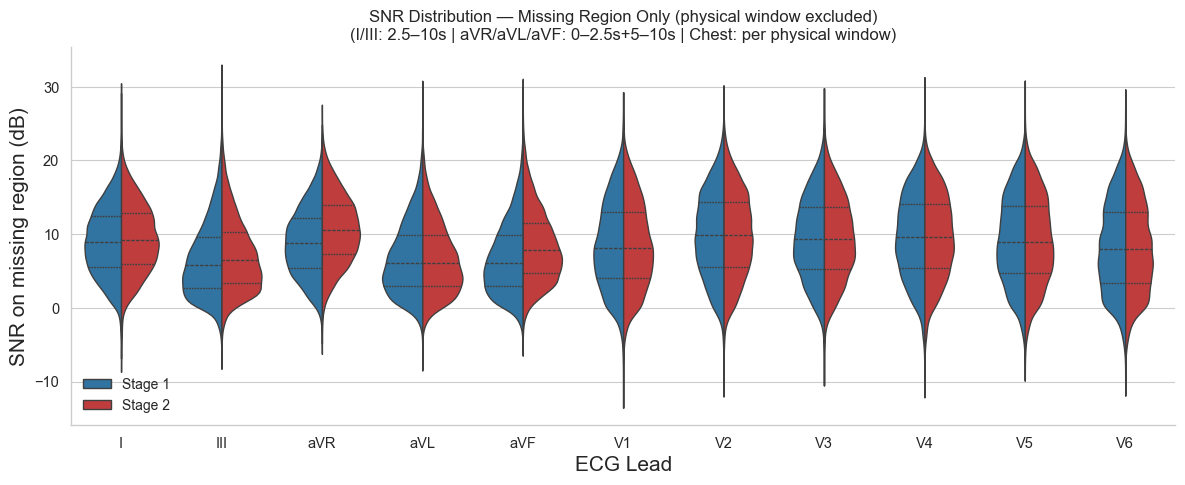

✓ Saved → /Users/sinahassannia/Desktop/ecg_lead_cover2/denoising_results3/violin_snr_missing_v3.png


In [12]:
import seaborn as sns

violin_data = []
for res in results_list:
    for lead in LEAD_NAMES:
        if lead == 'II':
            continue
        violin_data.append({'Lead': lead, 'SNR (dB)': res['snr_rec_missing'][lead],
                            'Stage': 'Stage 1'})
        violin_data.append({'Lead': lead, 'SNR (dB)': res['snr_den_missing'][lead],
                            'Stage': 'Stage 2'})

df_v = pd.DataFrame(violin_data)
df_v = df_v[np.isfinite(df_v['SNR (dB)'])]

sns.set(style='whitegrid', context='paper', font_scale=1.2)
fig, ax = plt.subplots(figsize=(12, 5))
sns.violinplot(data=df_v, x='Lead', y='SNR (dB)', hue='Stage',
               split=True, inner='quartile', linewidth=1,
               palette=['#1f77b4', '#d62728'], ax=ax)
ax.set_xlabel('ECG Lead', fontsize=15)
ax.set_ylabel('SNR on missing region (dB)', fontsize=15)
ax.set_title(
    'SNR Distribution — Missing Region Only (physical window excluded)\n'
    '(I/III: 2.5–10s | aVR/aVL/aVF: 0–2.5s+5–10s | Chest: per physical window)',
    fontsize=12
)
ax.legend(title='', frameon=False, fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}violin_snr_missing_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved → {RESULTS_DIR}violin_snr_missing_v3.png")